            # eReefs demo notebook

            This notebook demonstrates the refactored `ereefs` toolkit on small synthetic EMS-style NetCDF files. It covers the main documented local workflows:

            - regular and curvilinear grid discovery
            - standard and smoother display maps
            - surface, bottom, and depth-specific time series
            - depth-averaged and depth-below-free-surface extraction
            - vertical profiles
            - transect slices where the requested line does not exactly pass through cell centres
            


In [1]:
            repo_root <- if (file.exists("DESCRIPTION")) getwd() else normalizePath("..", winslash = "/", mustWork = TRUE)
            .libPaths(c(file.path(repo_root, ".r_libs"), .libPaths()))

            suppressPackageStartupMessages({
              library(pkgload)
              library(dplyr)
              library(ggplot2)
              library(tibble)
            })

            pkgload::load_all(repo_root)
            source(file.path(repo_root, "notebooks", "create_demo_datasets.R"))
            demo_paths <- create_demo_datasets(file.path(repo_root, "notebooks", "demo_data"))
            demo_paths
            


Warning message:
"package 'dplyr' was built under R version 4.3.3"


Warning message:
"package 'tibble' was built under R version 4.3.3"


ℹ Loading ereefs


$regular
[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/demo_data/regular_demo_2020-01.nc"

$regular_noeta
[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/demo_data/regular_demo_noeta_2020-01.nc"

$curvilinear
[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/demo_data/curvilinear_demo_2020-01.nc"

In [2]:
            notebook_output_dir <- file.path(repo_root, "notebooks", "output", "local_demo")
            dir.create(notebook_output_dir, recursive = TRUE, showWarnings = FALSE)

            save_plot_display <- function(plot_obj, filename, width = 8, height = 6, dpi = 120) {
              out_path <- file.path(notebook_output_dir, filename)
              ggplot2::ggsave(out_path, plot = plot_obj, width = width, height = height, dpi = dpi)
              print(plot_obj)
              out_path
            }
            


In [3]:
            regular_grids <- get_ereefs_grids(demo_paths$regular)
            curvilinear_grids <- get_ereefs_grids(demo_paths$curvilinear)

            list(
              regular = list(
                grid_type = regular_grids$grid_type,
                x_grid_dim = dim(regular_grids$x_grid),
                y_grid_dim = dim(regular_grids$y_grid),
                n_cells = nrow(regular_grids$spatial_grid)
              ),
              curvilinear = list(
                grid_type = curvilinear_grids$grid_type,
                x_grid_dim = dim(curvilinear_grids$x_grid),
                y_grid_dim = dim(curvilinear_grids$y_grid),
                n_cells = nrow(curvilinear_grids$spatial_grid)
              )
            )
            


$regular
$regular$grid_type
[1] "regular"

$regular$x_grid_dim
[1] 5 4

$regular$y_grid_dim
[1] 5 4

$regular$n_cells
[1] 12


$curvilinear
$curvilinear$grid_type
[1] "curvilinear"

$curvilinear$x_grid_dim
[1] 4 5

$curvilinear$y_grid_dim
[1] 4 5

$curvilinear$n_cells
[1] 12

[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/output/local_demo/regular_map_polygon.png"

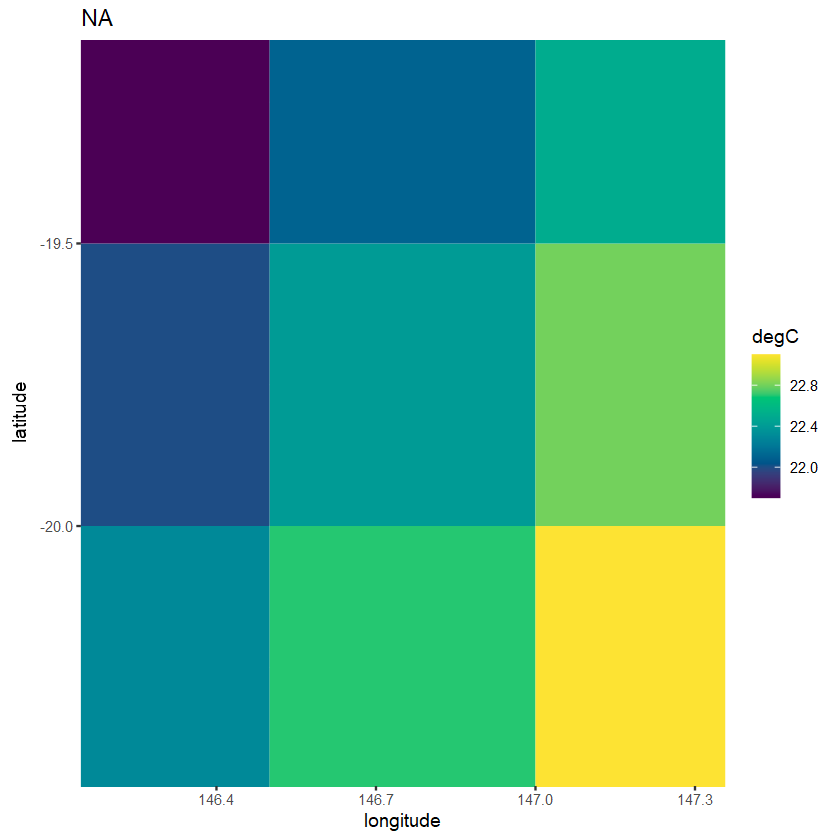

[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/output/local_demo/regular_map_smooth.png"

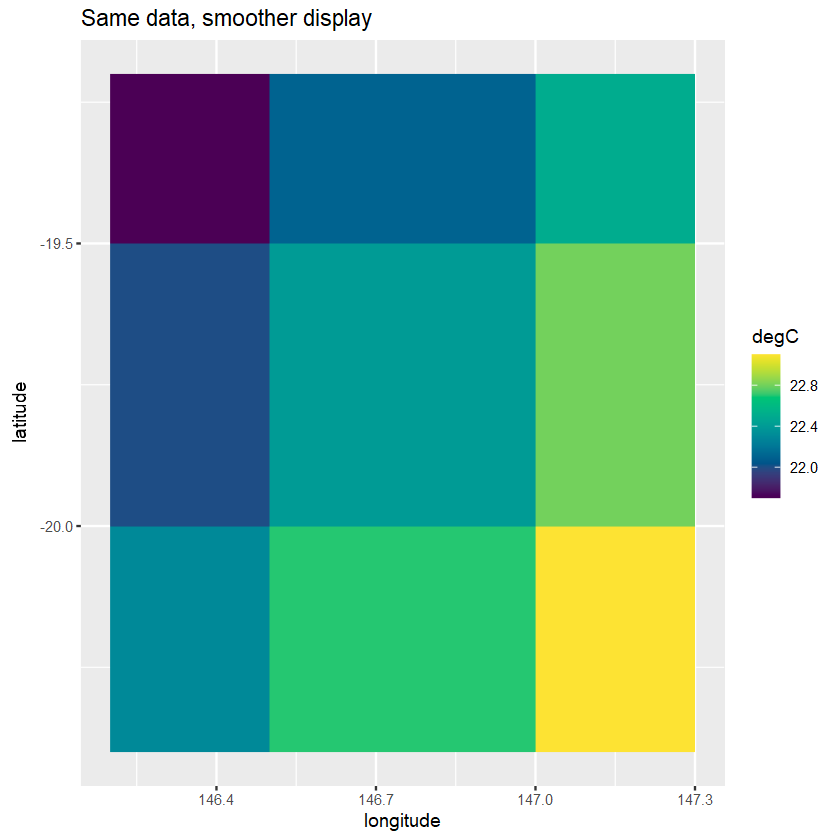

In [4]:
            box <- c(146.2, 147.3, -20.4, -19.2)

            regular_map_polygon <- map_ereefs(
              var_name = "temp",
              target_date = as.Date("2020-01-02"),
              layer = "surface",
              input_file = demo_paths$regular,
              box_bounds = box,
              scale_col = "viridis",
              suppress_print = TRUE,
              return_poly = TRUE,
              label_towns = FALSE
            )

            regular_map_plot <- plot_map(
              regular_map_polygon,
              box_bounds = box,
              scale_col = "viridis",
              suppress_print = TRUE,
              label_towns = FALSE
            )
            save_plot_display(regular_map_plot, "regular_map_polygon.png")

            regular_map_smooth <- plot_map(
              regular_map_polygon,
              box_bounds = box,
              scale_col = "viridis",
              plot_style = "smooth",
              smooth_pixels = 400,
              suppress_print = TRUE,
              label_towns = FALSE,
              var_longname = "Same data, smoother display"
            )
            save_plot_display(regular_map_smooth, "regular_map_smooth.png")
            


In [5]:
            ts_surface <- get_ereefs_ts(
              var_names = c("temp", "salt"),
              geocoordinates = tibble(latitude = -19.75, longitude = 146.75),
              layer = "surface",
              start_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2020-01-03 00:00:00", tz = "Etc/GMT-10"),
              input_file = demo_paths$regular,
              verbosity = 0
            )

            ts_bottom <- get_ereefs_ts(
              var_names = "temp",
              geocoordinates = tibble(latitude = -19.75, longitude = 146.75),
              layer = "bottom",
              start_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2020-01-03 00:00:00", tz = "Etc/GMT-10"),
              input_file = demo_paths$regular,
              verbosity = 0
            )

            ts_msl <- get_ereefs_ts(
              var_names = "temp",
              geocoordinates = tibble(latitude = -19.75, longitude = 146.75),
              layer = -5,
              start_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2020-01-03 00:00:00", tz = "Etc/GMT-10"),
              input_file = demo_paths$regular,
              verbosity = 0
            )

            list(
              surface_head = head(ts_surface),
              bottom_head = head(ts_bottom),
              depth_below_msl_head = head(ts_msl)
            )
            


$surface_head
# A tibble: 3 × 9
  latitude longitude     i     j cell_latitude cell_longitude
     <dbl>     <dbl> <int> <int>         <dbl>          <dbl>
1    -19.8      147.     2     2         -19.8           147.
2    -19.8      147.     2     2         -19.8           147.
3    -19.8      147.     2     2         -19.8           147.
# ℹ 3 more variables: time <dttm>, temp <dbl>, salt <dbl>

$bottom_head
# A tibble: 3 × 8
  latitude longitude     i     j cell_latitude cell_longitude
     <dbl>     <dbl> <int> <int>         <dbl>          <dbl>
1    -19.8      147.     2     2         -19.8           147.
2    -19.8      147.     2     2         -19.8           147.
3    -19.8      147.     2     2         -19.8           147.
# ℹ 2 more variables: time <dttm>, temp <dbl>

$depth_below_msl_head
# A tibble: 3 × 8
  latitude longitude     i     j cell_latitude cell_longitude
     <dbl>     <dbl> <int> <int>         <dbl>          <dbl>
1    -19.8      147.     2     2         -19.8           147.
2    -19.8      147.     2     2         -19.8           147.
3    -19.8      147.     2     2         -19.8           147.
# ℹ 2 more variables: time <dttm>, temp <dbl>

In [6]:
            depth_avg <- get_ereefs_depth_integrated_ts(
              var_names = "temp",
              geocoordinates = tibble(latitude = -19.75, longitude = 146.75),
              start_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2020-01-03 00:00:00", tz = "Etc/GMT-10"),
              input_file = demo_paths$regular,
              verbosity = 0
            )

            eta_warning <- NULL
            depth_free_surface <- withCallingHandlers(
              get_ereefs_depth_specified_ts(
                var_names = "temp",
                geocoordinates = tibble(latitude = -19.75, longitude = 146.75),
                depth = 2,
                start_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
                end_date = as.POSIXct("2020-01-03 00:00:00", tz = "Etc/GMT-10"),
                input_file = demo_paths$regular_noeta,
                verbosity = 0
              ),
              warning = function(w) {
                eta_warning <<- conditionMessage(w)
                invokeRestart("muffleWarning")
              }
            )

            list(
              depth_average_head = head(depth_avg),
              depth_below_free_surface_head = head(depth_free_surface),
              no_eta_warning = eta_warning
            )
            


$depth_average_head
# A tibble: 3 × 9
  latitude longitude     i     j cell_latitude cell_longitude
     <dbl>     <dbl> <int> <int>         <dbl>          <dbl>
1    -19.8      147.     2     2         -19.8           147.
2    -19.8      147.     2     2         -19.8           147.
3    -19.8      147.     2     2         -19.8           147.
# ℹ 3 more variables: time <dttm>, watercol_depth <dbl>, temp <dbl>

$depth_below_free_surface_head
# A tibble: 3 × 8
  latitude longitude     i     j cell_latitude cell_longitude
     <dbl>     <dbl> <int> <int>         <dbl>          <dbl>
1    -19.8      147.     2     2         -19.8           147.
2    -19.8      147.     2     2         -19.8           147.
3    -19.8      147.     2     2         -19.8           147.
# ℹ 2 more variables: time <dttm>, temp <dbl>

$no_eta_warning
[1] "eta is not available in this dataset, so depth-below-free-surface calculations are assuming eta = 0."

Warning message in max(wet):
"no non-missing arguments to max; returning -Inf"


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_path()`)."


Warning message:
"Removed 3 rows containing missing values or values outside the scale range
(`geom_path()`)."


[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/output/local_demo/curvilinear_profile.png"

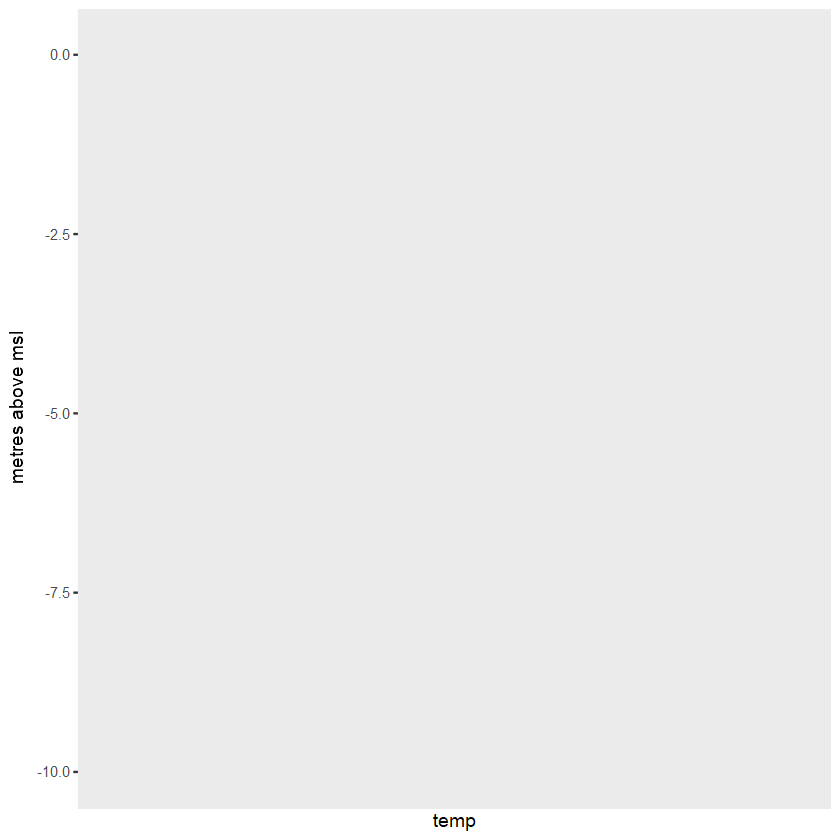

In [7]:
            profile <- get_ereefs_profile(
              var_names = "temp",
              geolocation = c(-19.4, 147.75),
              start_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
              end_date = as.POSIXct("2020-01-02 00:00:00", tz = "Etc/GMT-10"),
              input_file = demo_paths$curvilinear
            )

            profile_plot <- plot_ereefs_profile(profile, var_name = "temp", target_date = as.Date("2020-01-01"))
            save_plot_display(profile_plot, "curvilinear_profile.png")
            


[1] "C:/Users/brobson/OneDrive - Australian Institute of Marine Science/Code/eReefs R toolkit/ereefs/notebooks/output/local_demo/curvilinear_slice.png"

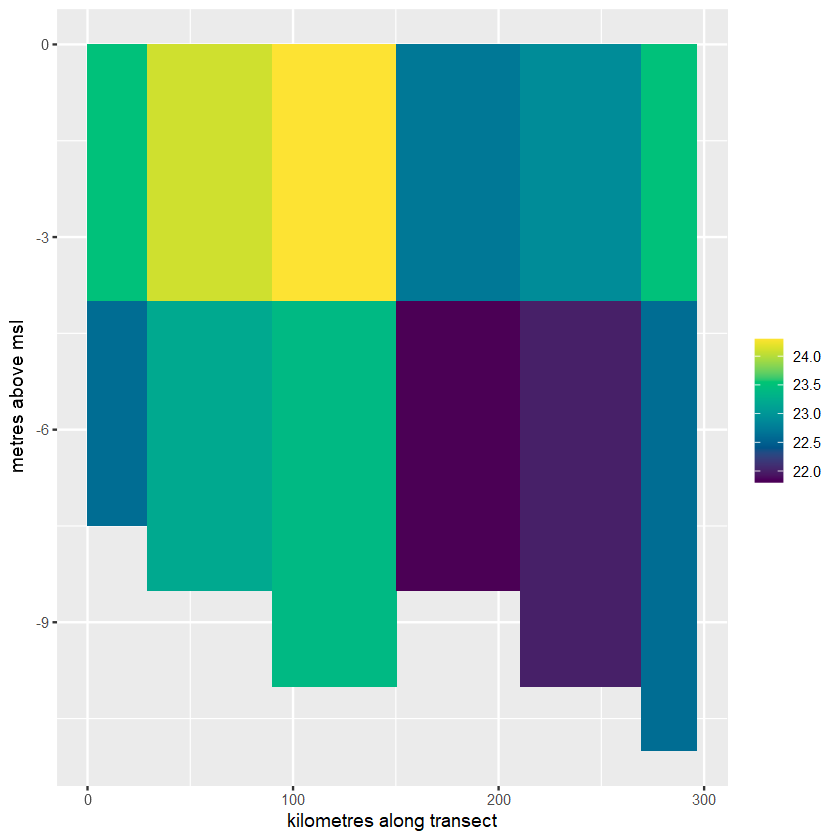

In [8]:
            slice <- get_ereefs_slice(
              var_names = "temp",
              geolocation = data.frame(
                latitude = c(-20.05, -18.7),
                longitude = c(147.05, 148.35)
              ),
              target_date = as.POSIXct("2020-01-01 00:00:00", tz = "Etc/GMT-10"),
              input_file = demo_paths$curvilinear
            )

            slice_plot <- plot_ereefs_slice(slice, var_name = "temp", scale_col = "viridis")
            save_plot_display(slice_plot, "curvilinear_slice.png", width = 9, height = 5)
            
